# **UCI HAR - CNN Classification**

# Data set 분석
- UCI HAR (Human Activity Recognition)
- 무엇을 측정한 데이터인가?
  - 사람이 스마트폰을 허리에 착용하고 6가지 동작을 수행했을 때, 폰 안에 들어있는 두 가지 핵심 센서의 값을 기록한 데이터
  - Accelerometer : 가속도 센서 (움직임의 세기, 중력의 방향, 급격한 속도 변화 등)
  - Gyroscope : 자이로스코프 센서 (스마트폰이 얼마나 회전하는지, 어떤 각도로 기울어져 있는지)
- 맞혀야 할 정답(Label)은?
  - 이 사람이 지금 무엇을 하고 있는지
    1. Walking (걷기)
    2. Walking Upstairs (계단 오르기)
    3. Walking Downstairs (계단 내려가기)
    4. Sitting (앉아 있기)
    5. Standing (서 있기)
    6. Laying (누워 있기)
- X / y 데이터 형태
  - 초당 수십 번씩 파동하는 복잡한 센서 신호 > 분석하기 좋게 미리 *561개의 특징(Features)*으로 가공해둔 상태
  - ex. avg, max, min ... > 숫자들이 한 세트가 되어서 > 이 신호는 '걷기'이다.



---



In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, Conv1D, BatchNormalization, ReLU, MaxPooling1D, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

In [ ]:
TRAIN = "train/"
TEST = "test/"

DATASET_PATH = "/content/drive/MyDrive/AI_assignment/UCI_HAR_Dataset/"

In [ ]:
# Load "X"
def load_X(X_signals_paths):
    X_signals = []

    for signal_type_path in X_signals_paths:
        series_list = []  # 한 센서축 데이터 전체 저장

        with open(signal_type_path, 'r') as file:
            for row in file:
                row_clean = row.replace('  ', ' ') # 공백 2개를 1개로
                row_clean = row_clean.strip() # 양쪽 공백 제거
                serie = row_clean.split(' ') # 공백 기준 split
                serie_array = np.array(serie, dtype=np.float32) # float32 numpy 배열로 변환
                series_list.append(serie_array) # 시퀀스 추가

        # 하나의 센서축 데이터 추가 (feature)
        X_signals.append(series_list)

    # shape: (특성 수, 샘플 수, 타임스텝 수)
    X_signals = np.array(X_signals)
    # shape 변환 → (샘플 수, 타임스텝 수, 특성 수)
    return np.transpose(X_signals, (1, 2, 0))


X_train_signals_paths = [
    DATASET_PATH + TRAIN + "Inertial_Signals/" + signal + "train.txt"
    for signal in INPUT_SIGNAL_TYPES
]
X_test_signals_paths = [
    DATASET_PATH + TEST + "Inertial_Signals/" + signal + "test.txt"
    for signal in INPUT_SIGNAL_TYPES
]

X_train = load_X(X_train_signals_paths)
X_test = load_X(X_test_signals_paths)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("첫 번째 샘플 데이터:\n", X_train[0])

X_train shape: (7352, 128, 9)
X_test shape: (2947, 128, 9)
첫 번째 샘플 데이터:
 [[ 1.808515e-04  1.076681e-02  5.556068e-02 ...  1.012817e+00
  -1.232167e-01  1.029341e-01]
 [ 1.013856e-02  6.579480e-03  5.512483e-02 ...  1.022833e+00
  -1.268756e-01  1.056872e-01]
 [ 9.275574e-03  8.928878e-03  4.840473e-02 ...  1.022028e+00
  -1.240037e-01  1.021025e-01]
 ...
 [-1.147484e-03  1.714439e-04  2.647864e-03 ...  1.018445e+00
  -1.240696e-01  1.003852e-01]
 [-2.222655e-04  1.574181e-03  2.381057e-03 ...  1.019372e+00
  -1.227451e-01  9.987355e-02]
 [ 1.575500e-03  3.070189e-03 -2.269757e-03 ...  1.021171e+00
  -1.213260e-01  9.498741e-02]]


In [ ]:
# Load "y"

def load_y(y_path):
    with open(y_path, 'r') as file:
        labels = [int(line.strip()) for line in file]
    # 라벨을 0부터 시작하도록 -1 (원래 라벨이 1부터 시작)
    return np.array(labels, dtype=np.int32) - 1


y_train_path = DATASET_PATH + TRAIN + "y_train.txt"
y_test_path = DATASET_PATH + TEST + "y_test.txt"

y_train = load_y(y_train_path)
y_test = load_y(y_test_path)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print(y_train[:5])

y_train shape: (7352,)
y_test shape: (2947,)
[4 4 4 4 4]


# 1D CNN (1차원 합성곱 신경망) 설계
- Layer
  - Conv1D 층 3개 + Dense 층 2개
- Output Shape 변화
  - Input data : (None, 128, 9)
  - max_pooling1d : (None, 64, 128)
  - global_average_pooling1d : (None, 256) > Time 차원이 사라짐
- Params
  - 모델이 갖는 총 파라미터 : 161,670개
  - 실제로 학습하면서 업데이트할 수 있는 파라미터 : 160,774개

In [ ]:
input_shape = (X_train.shape[1], X_train.shape[2])
num_classes = 6

model = Sequential([
    Input(shape=input_shape),

    # 첫 번째 특징 추출
    Conv1D(64, 5, padding='same'),
    BatchNormalization(),
    ReLU(),

    # 두 번째 특징 추출 (+ MaxPooling으로 압축)
    Conv1D(128, 3, padding='same'),
    BatchNormalization(),
    ReLU(),
    MaxPooling1D(2),

    # 세 번째 특징 추출
    Conv1D(256, 3, padding='same'),
    BatchNormalization(),
    ReLU(),

    # 차원 축소 및 데이터 요약 : 1차원 벡터
    GlobalAveragePooling1D(),

    # 추출된 특징들을 조합하는 은닉층
    Dense(128, activation='relu'),
    Dropout(0.3),

    # 최종적으로 6가지 행동 중 하나를 결정하는 출력 층
    Dense(num_classes, activation='softmax')
])

# 컴파일 설정
model.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy', # 정답이 One-hot 형태가 아닌 정수 형태일 때 사용하는 손실 함수
            metrics=['sparse_categorical_accuracy']
        )

print(model.summary())

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_15 (Conv1D)              │ (None, 128, 64)        │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_15 (ReLU)                 │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_16 (Conv1D)              │ (None, 128, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 128, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_16 (ReLU)                 │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 64, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 64, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_17 (ReLU)                 │ (None, 64, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_5      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161,670 (631.52 KB)

 Trainable params: 160,774 (628.02 KB)

 Non-trainable params: 896 (3.50 KB)

None


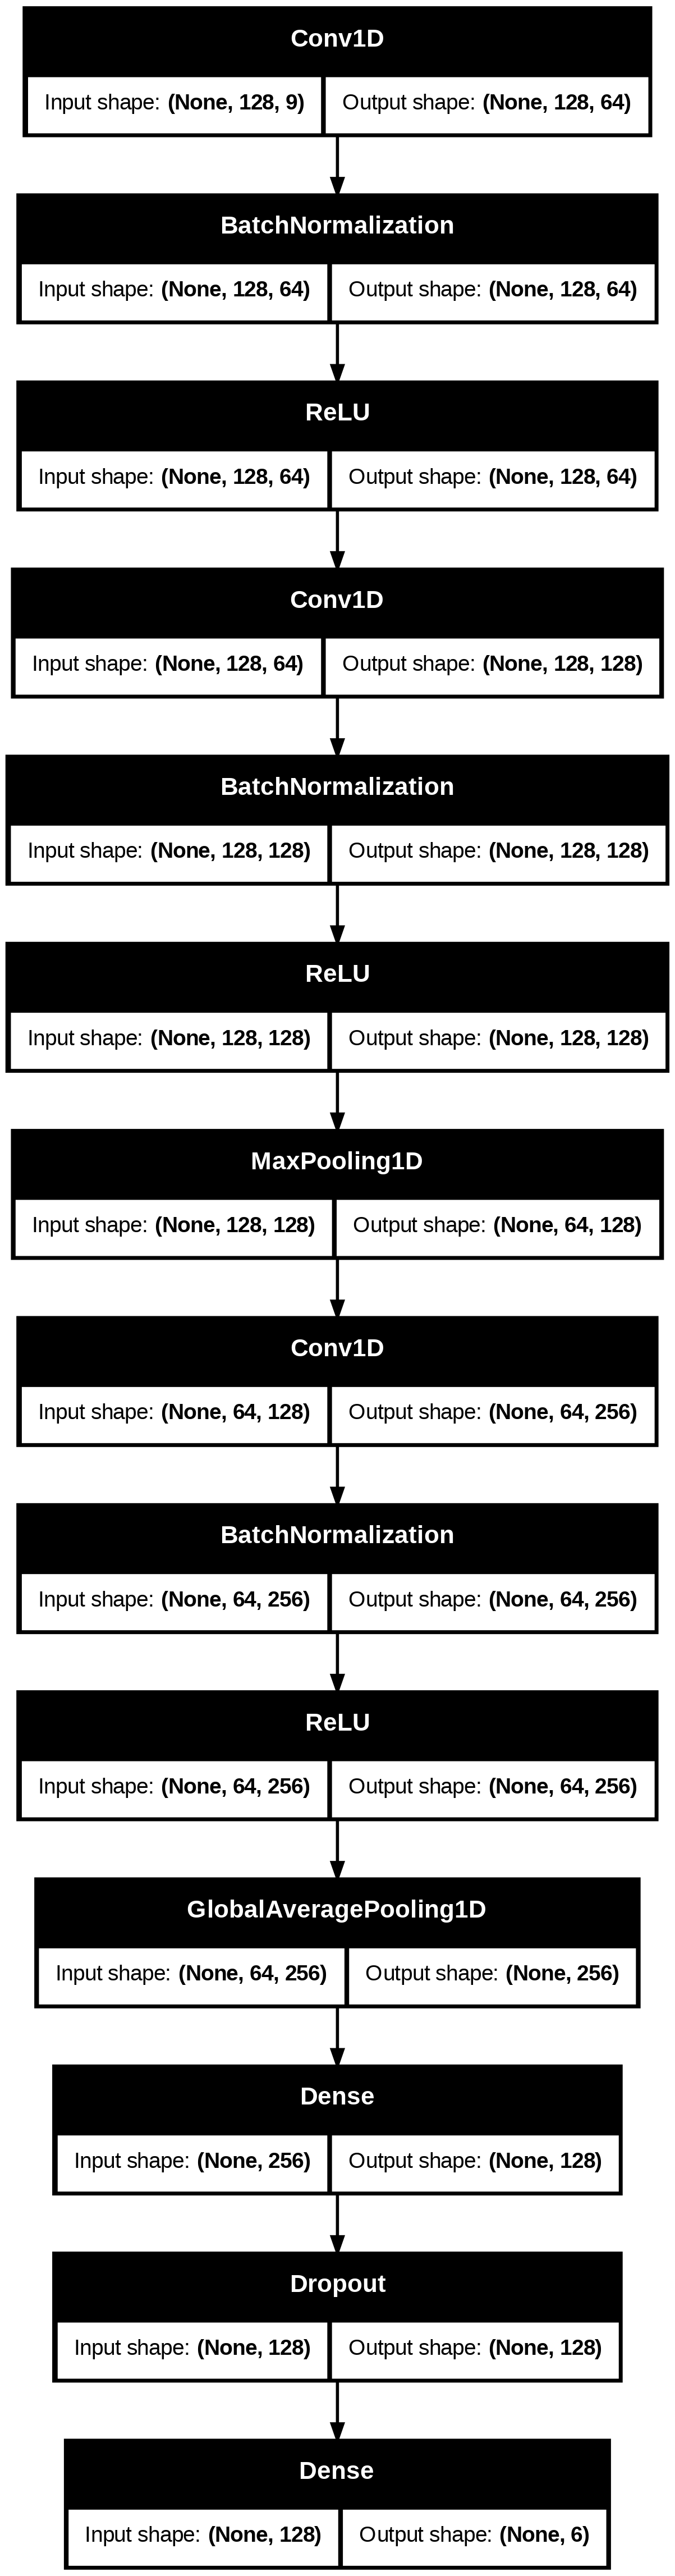

In [ ]:
tf.keras.utils.plot_model(model, show_shapes=True)

# callbacks
- 학습 도중 특정 상황이 되면 자동으로 실행되는 제어 장치
  - ModelCheckpoint (자동 저장) : "학습하다가 best 성적 나오면 그때의 모델을 파일로 저장해둬."
  - EarlyStopping (조기 종료) : "더이상 학습해도 성적이 더 안 오르면 중간에 학습 끝내버려."
  - ReduceLROnPlateau (학습률 조정) : "성적이 정체되면 Learning Rate를 조금 낮춰서 꼼꼼하게 살펴봐."

In [ ]:
callbacks = [
            ModelCheckpoint(
                "UCI_HAR_CNN_best.h5",
                save_best_only=True,
                monitor="val_sparse_categorical_accuracy",
                mode='max',
                verbose=1
            ),
            EarlyStopping(
                monitor="val_sparse_categorical_accuracy",
                patience=30,
                verbose=1,
                mode='max',
                restore_best_weights=True
            ),
            ReduceLROnPlateau(
                monitor='val_loss',    # val_loss 값을 지켜보다가
                factor=0.2,            # 학습에 발전이 없으면 LR에 0.2를 곱함 (기존의 1/5 수준으로 감소)
                patience=5,            # 5번 epochs 동안 성적이 안 오르면 실행
                min_lr=0.00001,        # 최소 LR 지정
                verbose=1              # LR이 바뀔 때 화면에 메시지 출력
            )
        ]

# 모델 학습
- epochs : 전체 데이터 반복 횟수
- batch size : 몇개씩 묶어서 학습할지
- validation_split : 학습데이터 중 몇 퍼센트를 검증데이터로 사용할지 (학습이 잘 되고 있는지 스스로 체크)
- history : 학습 과정(정확도 변화, 손실값 변화) 기록

In [ ]:
history = model.fit(
            X_train, y_train,
            epochs=100,
            batch_size=64,
            validation_split=0.2,
            callbacks=callbacks,
            verbose=1
        )

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.0674 - sparse_categorical_accuracy: 0.9668
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.91842, saving model to UCI_HAR_CNN_best.h5



Epoch 1: finished saving model to UCI_HAR_CNN_best.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 141ms/step - loss: 0.0704 - sparse_categorical_accuracy: 0.9662 - val_loss: 0.3449 - val_sparse_categorical_accuracy: 0.9184 - learning_rate: 4.0000e-05
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 0.0648 - sparse_categorical_accuracy: 0.9675
Epoch 2: val_sparse_categorical_accuracy improved from 0.91842 to 0.91978, saving model to UCI_HAR_CNN_best.h5



Epoch 2: finished saving model to UCI_HAR_CNN_best.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 145ms/step - loss: 0.0678 - sparse_categorical_accuracy: 0.9675 - val_loss: 0.3490 - val_sparse_categorical_accuracy: 0.9198 - learning_rate: 4.0000e-05
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 0.0642 - sparse_categorical_accuracy: 0.9678
Epoch 3: val_sparse_categorical_accuracy did not improve from 0.91978
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 144ms/step - loss: 0.0675 - sparse_categorical_accuracy: 0.9663 - val_loss: 0.3617 - val_sparse_categorical_accuracy: 0.9191 - learning_rate: 4.0000e-05
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 0.0649 - sparse_categorical_accuracy: 0.9677
Epoch 4: val_sparse_categorical_accuracy improved from 0.91978 to 0.92114, saving model to UCI_HAR_CNN_best.h5



Epoch 4: finished saving model to UCI_HAR_CNN_best.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 146ms/step - loss: 0.0670 - sparse_categorical_accuracy: 0.9658 - val_loss: 0.3589 - val_sparse_categorical_accuracy: 0.9211 - learning_rate: 4.0000e-05
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.0718 - sparse_categorical_accuracy: 0.9660
Epoch 5: val_sparse_categorical_accuracy did not improve from 0.92114
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 131ms/step - loss: 0.0684 - sparse_categorical_accuracy: 0.9680 - val_loss: 0.3576 - val_sparse_categorical_accuracy: 0.9205 - learning_rate: 4.0000e-05
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 0.0647 - sparse_categorical_accuracy: 0.9646
Epoch 6: val_sparse_categorical_accuracy improved from 0.92114 to 0.92522, saving model to UCI_HAR_CNN_best.h5



Epoch 6: finished saving model to UCI_HAR_CNN_best.h5

Epoch 6: ReduceLROnPlateau reducing learning rate to 1e-05.
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 145ms/step - loss: 0.0675 - sparse_categorical_accuracy: 0.9655 - val_loss: 0.3548 - val_sparse_categorical_accuracy: 0.9252 - learning_rate: 4.0000e-05
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 0.0651 - sparse_categorical_accuracy: 0.9672
Epoch 7: val_sparse_categorical_accuracy improved from 0.92522 to 0.92794, saving model to UCI_HAR_CNN_best.h5



Epoch 7: finished saving model to UCI_HAR_CNN_best.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 149ms/step - loss: 0.0659 - sparse_categorical_accuracy: 0.9668 - val_loss: 0.3568 - val_sparse_categorical_accuracy: 0.9279 - learning_rate: 1.0000e-05
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 0.0674 - sparse_categorical_accuracy: 0.9641
Epoch 8: val_sparse_categorical_accuracy improved from 0.92794 to 0.93066, saving model to UCI_HAR_CNN_best.h5



Epoch 8: finished saving model to UCI_HAR_CNN_best.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 154ms/step - loss: 0.0671 - sparse_categorical_accuracy: 0.9655 - val_loss: 0.3570 - val_sparse_categorical_accuracy: 0.9307 - learning_rate: 1.0000e-05
Epoch 9/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.0685 - sparse_categorical_accuracy: 0.9669
Epoch 9: val_sparse_categorical_accuracy did not improve from 0.93066
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 147ms/step - loss: 0.0667 - sparse_categorical_accuracy: 0.9684 - val_loss: 0.3577 - val_sparse_categorical_accuracy: 0.9307 - learning_rate: 1.0000e-05
Epoch 10/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - loss: 0.0641 - sparse_categorical_accuracy: 0.9688
Epoch 10: val_sparse_categorical_accuracy did not improve from 0.93066
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - loss: 0.0652 - sparse_categorical_accuracy: 0.9696 - val_loss: 0.3575 - val_sparse_categorical_accuracy: 0.9307 - learning_rate: 1.0000e-05
Epoch 11/100
92/92 ━━━━━━━━━━━━━━━━━━━━


Epoch 11: finished saving model to UCI_HAR_CNN_best.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 135ms/step - loss: 0.0668 - sparse_categorical_accuracy: 0.9668 - val_loss: 0.3626 - val_sparse_categorical_accuracy: 0.9313 - learning_rate: 1.0000e-05
Epoch 12/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 0.0723 - sparse_categorical_accuracy: 0.9648
Epoch 12: val_sparse_categorical_accuracy did not improve from 0.93134
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 146ms/step - loss: 0.0715 - sparse_categorical_accuracy: 0.9660 - val_loss: 0.3579 - val_sparse_categorical_accuracy: 0.9300 - learning_rate: 1.0000e-05
Epoch 13/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 0.0622 - sparse_categorical_accuracy: 0.9704
Epoch 13: val_sparse_categorical_accuracy did not improve from 0.93134
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 138ms/step - loss: 0.0678 - sparse_categorical_accuracy: 0.9663 - val_loss: 0.3556 - val_sparse_categorical_accuracy: 0.9307 - learning_rate: 1.0000e-05
Epoch 14/100
92/92 ━━━━━━━━━━━━━━━━━


Epoch 22: finished saving model to UCI_HAR_CNN_best.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 148ms/step - loss: 0.0660 - sparse_categorical_accuracy: 0.9701 - val_loss: 0.3584 - val_sparse_categorical_accuracy: 0.9320 - learning_rate: 1.0000e-05
Epoch 23/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 0.0727 - sparse_categorical_accuracy: 0.9663
Epoch 23: val_sparse_categorical_accuracy did not improve from 0.93202
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 144ms/step - loss: 0.0704 - sparse_categorical_accuracy: 0.9670 - val_loss: 0.3548 - val_sparse_categorical_accuracy: 0.9320 - learning_rate: 1.0000e-05
Epoch 24/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 0.0673 - sparse_categorical_accuracy: 0.9669
Epoch 24: val_sparse_categorical_accuracy did not improve from 0.93202
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 146ms/step - loss: 0.0672 - sparse_categorical_accuracy: 0.9679 - val_loss: 0.3566 - val_sparse_categorical_accuracy: 0.9313 - learning_rate: 1.0000e-05
Epoch 25/100
92/92 ━━━━━━━━━━━━━━━━━


Epoch 36: finished saving model to UCI_HAR_CNN_best.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 138ms/step - loss: 0.0638 - sparse_categorical_accuracy: 0.9674 - val_loss: 0.3619 - val_sparse_categorical_accuracy: 0.9327 - learning_rate: 1.0000e-05
Epoch 37/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 0.0618 - sparse_categorical_accuracy: 0.9713
Epoch 37: val_sparse_categorical_accuracy did not improve from 0.93270
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 145ms/step - loss: 0.0644 - sparse_categorical_accuracy: 0.9696 - val_loss: 0.3651 - val_sparse_categorical_accuracy: 0.9327 - learning_rate: 1.0000e-05
Epoch 38/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 0.0648 - sparse_categorical_accuracy: 0.9699
Epoch 38: val_sparse_categorical_accuracy did not improve from 0.93270
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 145ms/step - loss: 0.0670 - sparse_categorical_accuracy: 0.9696 - val_loss: 0.3638 - val_sparse_categorical_accuracy: 0.9320 - learning_rate: 1.0000e-05
Epoch 39/100
92/92 ━━━━━━━━━━━━━━━━━

# 모델 평가

In [ ]:
# best 기록 확인
model = tf.keras.models.load_model("UCI_HAR_CNN_best.h5")

train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Training accuracy: 96.68%
Training loss: 0.1147
Test accuracy: 94.06%
Test loss: 0.2462


In [ ]:
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

# 분류 리포트
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9940    0.9970       496
           1     0.9510    0.9469    0.9489       471
           2     0.9374    0.9976    0.9666       420
           3     0.8557    0.8452    0.8504       491
           4     0.9006    0.8684    0.8842       532
           5     0.9944    1.0000    0.9972       537

    accuracy                         0.9406      2947
   macro avg     0.9398    0.9420    0.9407      2947
weighted avg     0.9402    0.9406    0.9402      2947



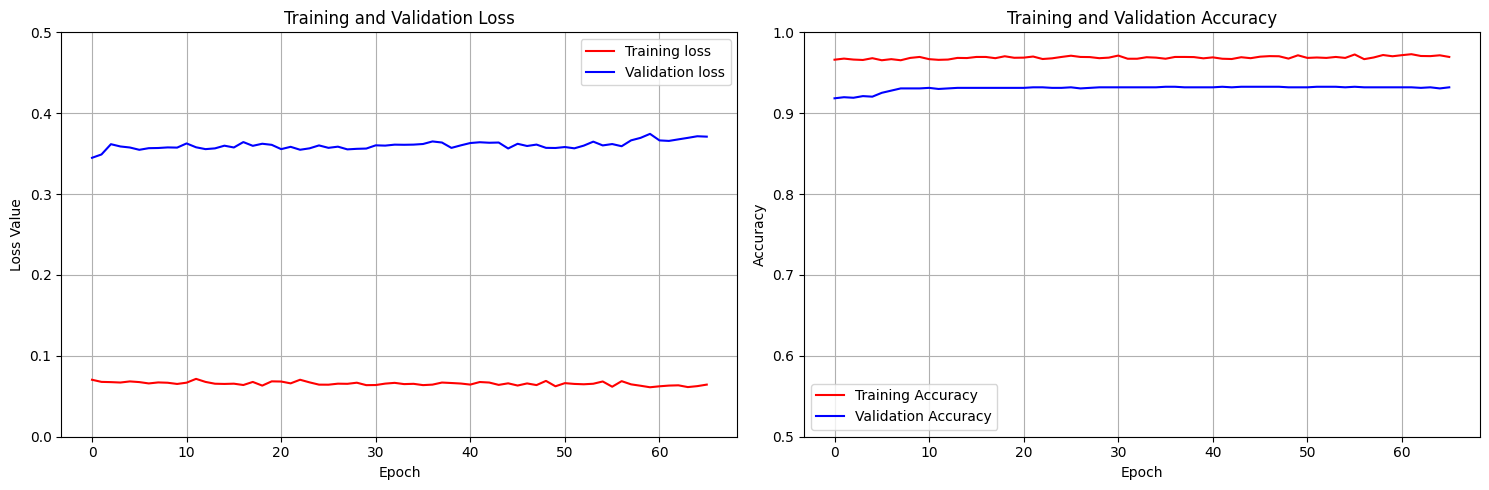

In [ ]:
train_loss = history.history['loss']
train_accuracy = history.history['sparse_categorical_accuracy']
val_loss = history.history['val_loss']
val_accuracy = history.history['val_sparse_categorical_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.ylim([0.0, 0.5])
plt.plot(train_loss, 'r', label='Training loss')
plt.plot(val_loss, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.ylim([0.5, 1.0])
plt.plot(train_accuracy, 'r', label='Training Accuracy')
plt.plot(val_accuracy, 'b', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

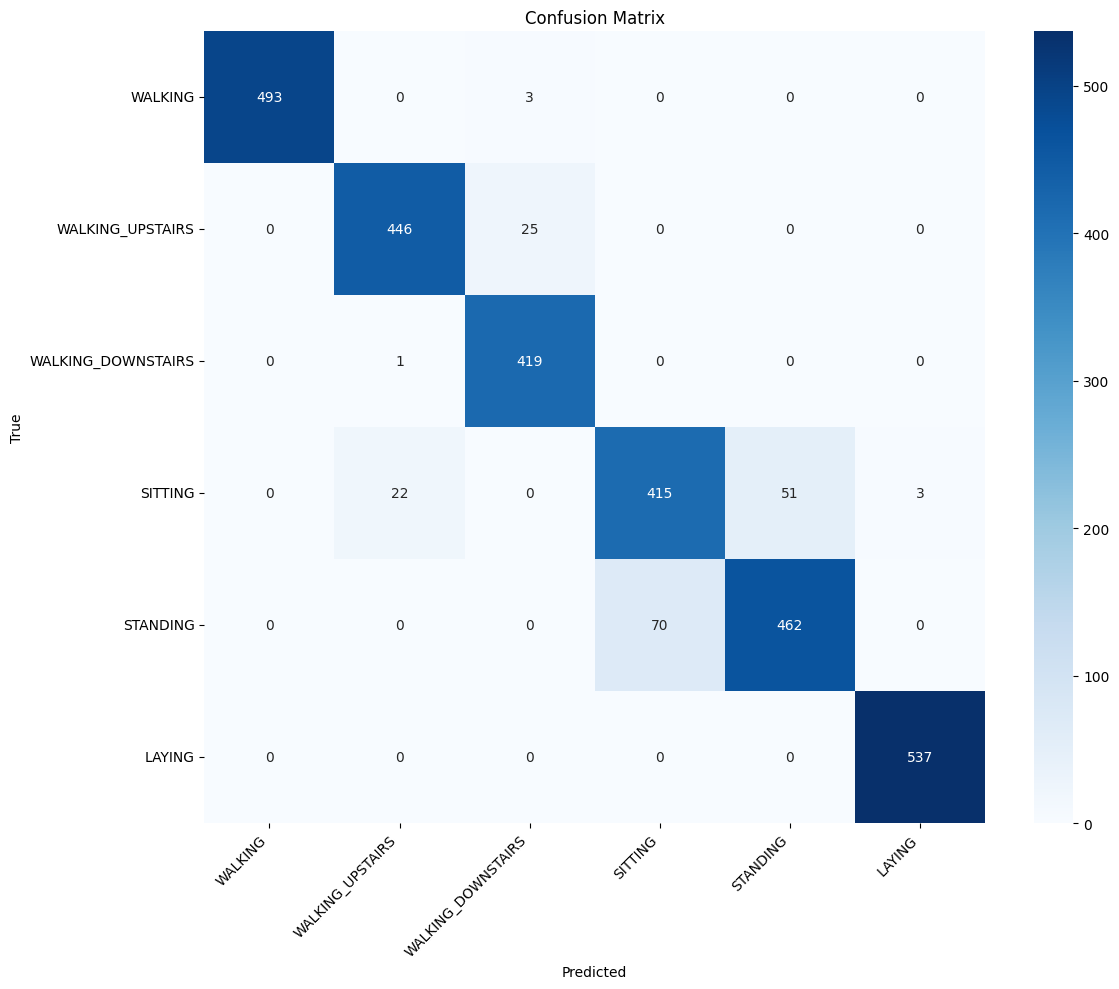

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

n_classes = len(np.unique(y_test))
if n_classes <= len(LABELS):
    plt.gca().set_xticklabels(LABELS[:n_classes], rotation=45, ha='right')
    plt.gca().set_yticklabels(LABELS[:n_classes], rotation=0)

plt.tight_layout()
plt.show()